Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/1 [00:00<?, ?it/s]

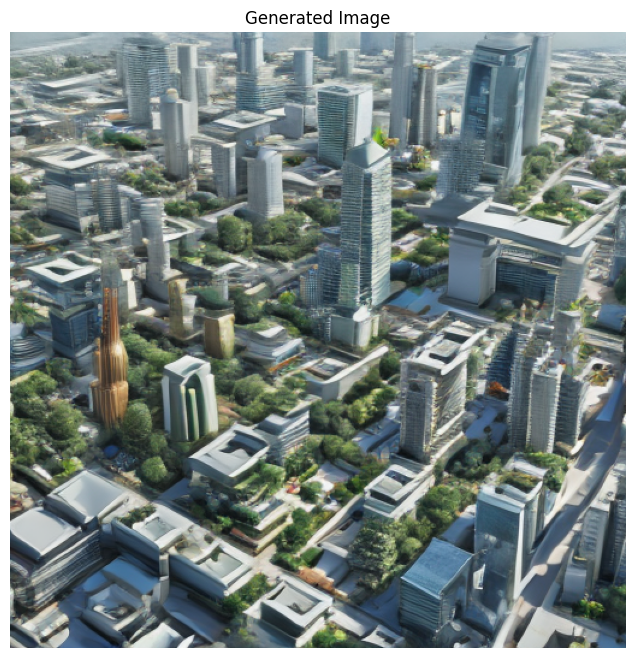

Image successfully generated and saved as generated_image.png


In [1]:
# Install required libraries
!pip install -q diffusers transformers accelerate torch pillow sentencepiece

import torch
import matplotlib.pyplot as plt
from diffusers import DiffusionPipeline

# Load a free Stable Diffusion model
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

# Select device
device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = pipe.to(device)

# Prompt
prompt = """
A futuristic smart city with flying cars,
green buildings, robots assisting people,
highly detailed, realistic, 4K quality.
"""

# Generate image
image = pipe(
    prompt,
    num_inference_steps=1,
    guidance_scale=0.0
).images[0]

# Save image
image.save("generated_image.png")

# Display image
plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.title("Generated Image")
plt.show()

print("Image successfully generated and saved as generated_image.png")